# Task 1 — Transcript Categorization

**Goal:** process all 100 transcripts and categorize them by topic/theme, explain the approach, and show examples per category.

## Approach: hybrid (LLM-proposed taxonomy, human-locked, then LLM classification)

I considered three approaches:

| Approach | Pros | Cons | Verdict |
|---|---|---|---|
| Pure embedding clustering | Fast, no labeling bias | Clusters need labeling anyway; with only 100 docs, clusters are noisy and don't reliably align with business concepts ("churn risk" isn't necessarily the tightest semantic cluster) | Rejected |
| Pure rule-based (keywords) | Fast, fully auditable | Brittle — this dataset's titles/content are varied enough that hand-written regexes need constant patching and miss nuance (e.g. distinguishing a churn-risk renewal call from a healthy one) | Rejected as primary, but used as a *supporting* signal for call-type detection |
| **Hybrid: LLM discovers taxonomy bottom-up → human reviews/locks → LLM classifies against fixed taxonomy** | Business-relevant categories (not guessed top-down by me), auditable per-call rationale, fast enough for 100 docs | Costs LLM tokens, taxonomy quality depends on the discovery sample | **Chosen** |

The key idea: rather than *me* guessing categories before looking closely at the data, I let the data propose its own structure first (Step 1), and only then did I converge it into something fixed and classifiable (Step 2-3). This avoids forcing 100 real, messy business calls into categories I assumed would exist.

In [1]:
import sys, os
sys.path.append("../src")
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from load_data import load_all_transcripts

sns.set_style("whitegrid")
df = load_all_transcripts()
print(df.shape)
df["call_type"].value_counts()

(100, 16)


call_type
external    43
internal    30
support     27
Name: count, dtype: int64

## Step 0: Call type derivation (prerequisite)

Call type (support / external / internal) isn't a field in the raw data — I derived it with a transparent heuristic:
- Title contains "Support Case" → **support**
- All participant emails share the `@aegiscloud.com` domain → **internal**
- Otherwise (Aegis + at least one external customer domain) → **external**

I validated this by eyeballing all 100 titles. It cleanly produces 43 external / 30 internal / 27 support calls — a realistic, balanced split matching the assignment's three call types, with no need to relabel or generate synthetic data (per the FAQ's allowance to do so if needed — wasn't needed here).

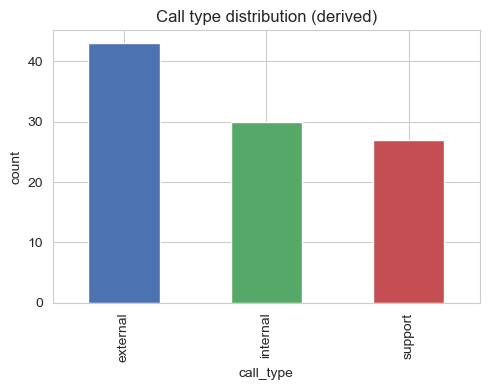

In [2]:
fig, ax = plt.subplots(figsize=(5,4))
df["call_type"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0","#55A868","#C44E52"])
ax.set_title("Call type distribution (derived)")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig("../outputs/figures/call_type_distribution.png", dpi=150)
plt.show()

## Step 1: Open-ended taxonomy discovery

I sampled ~20 transcripts, stratified across call types, and asked the LLM to propose 8-12 business-relevant categories bottom-up (not from a list I gave it).

In [3]:
from categorize import run_discovery
discovery = run_discovery(df)
import json
print(json.dumps(discovery, indent=2))

{
  "categories": [
    {
      "name": "Platform Outage & Incident Response",
      "description": "Calls related to service disruptions, outages, post-incident reviews, and technical root cause analysis. Includes both customer-facing recovery discussions and internal incident retrospectives.",
      "example_call_ids": [
        "01KQE110900B8A65D80AE694",
        "01KQ3CE40428CCC5FF433FFC",
        "01KQ5D47170D4828E89EDE37"
      ]
    },
    {
      "name": "Renewal Risk & Churn Prevention",
      "description": "Calls where customer retention is at risk due to dissatisfaction, competitive evaluation, or contract renewal concerns. Often involves service recovery efforts and relationship repair.",
      "example_call_ids": [
        "01KQ7FA71CF70FAFEE4B6251",
        "01KQC1267BEB344076DD7656",
        "01KQ56D878454E5783DC6D94"
      ]
    },
    {
      "name": "Product Onboarding & Implementation",
      "description": "Initial setup, deployment planning, and technical configur

## Step 2: Human review and convergence (manual step)

I reviewed the 12 categories the model proposed and made two edits before locking
the final taxonomy:

- **Merged "Post-Incident Customer Communication" into "Platform Reliability &
  Outages."** It only had 4 supporting calls and was really a downstream stage
  of the outage story (explaining impact, confirming recovery) rather than a
  distinct topic. The stage-level distinction isn't lost -- it's captured
  separately by `incident_stage` in the bonus insights notebook.
- **Merged "Usage & Capacity Management" into "Billing & Licensing Issues."**
  Only 2 supporting calls, and its own proposed description was framed entirely
  around billing impact of usage overages -- a sub-case of billing, not a
  separate theme.

I deliberately kept "Positive Renewal & Expansion" and "Renewal Risk & Churn
Prevention" as two separate categories even though both are renewal-stage
calls, because they call for opposite actions from an account team (intervene
vs. don't) -- collapsing them would lose exactly the distinction a CS leader
would want to triage on.

This brought the taxonomy from 12 categories down to 10, saved to
`outputs/taxonomy_FINAL.json`, which is what Step 3 below actually classifies
against.

In [4]:
# Load the FINAL (human-reviewed) taxonomy
final_path = "../outputs/taxonomy_FINAL.json"
if os.path.exists(final_path):
    with open(final_path) as f:
        taxonomy = json.load(f)["categories"]
else:
    print("No taxonomy_FINAL.json yet -- using raw discovery output as a placeholder.")
    print("In a real run: review discovery output above, edit it, save as taxonomy_FINAL.json, then re-run this cell.")
    taxonomy = discovery["categories"]

for c in taxonomy:
    print(f"- {c['name']}: {c['description']}")

- Platform Reliability & Outages: Calls addressing system downtime, service degradation, incident response, root cause analysis, post-incident remediation, and post-incident customer communication (explaining outage impact, providing incident documentation, confirming recovery). Includes both customer-facing discussions and internal engineering reviews of reliability issues. (Merged from two originally-proposed categories -- 'Platform Reliability & Outages' and 'Post-Incident Customer Communication' -- since the second was really a downstream stage of the same topic rather than a distinct theme; the bonus insights notebook's incident_stage field already captures that stage-level distinction for anyone who needs it.)
- Renewal Risk & Churn Prevention: Calls where contract renewal is at risk due to product issues, competitive evaluation, or customer dissatisfaction. Includes account recovery efforts and discussions of conditions required to retain the customer.
- Billing & Licensing Issu

## Step 3: Classify all 100 transcripts against the fixed taxonomy

Each call gets exactly one **primary category** (for clean aggregate stats) plus optional secondary categories (since real calls are rarely about exactly one thing — e.g. a renewal call that also surfaces a feature request), a confidence score, and a one-sentence rationale grounded in something specific from the call (for auditability — a leader can spot-check *why* a call got tagged a certain way).

In [5]:
from categorize import classify_all

# NOTE: this makes 100 LLM calls and will take a few minutes.
results = classify_all(df, taxonomy)
results.to_csv("../outputs/categorization_results.csv", index=False)
results.head(10)

  classifying 1/100: 01KQ03B0303900521BB089CA (Detect Outage - Remediation Plan Review)
  classifying 2/100: 01KQ0C1280EDA4E70AAD7C35 (Support Case #9279 - Summit Trust Billing Inquiry)
  classifying 3/100: 01KQ0CAE7F064EC93F0540CA (Weekly Engineering Standup)
  classifying 4/100: 01KQ0DFE299AC7A74E8022CA (Aegis / Redwood Clinical - ISO 27001 Preparation)
  classifying 5/100: 01KQ0F8AFF3DA34FD4580008 (Aegis / Cobalt Software - Q2 Planning)
  classifying 6/100: 01KQ1267C6AA7D9B3125FEC8 (SOC 2 Audit Preparation - Internal)
  classifying 7/100: 01KQ1A6B7E81B06F4A13B60D (Support Case #6977 - Brightpath Commerce Slow Back)
  classifying 8/100: 01KQ1DC6CA536DE1B31ED8F5 (Aegis / Atlas Precision - Contract Discussion)
  classifying 9/100: 01KQ1DCC80852AE384C898C9 (Aegis / Quantum Edge - Renewal Concerns)
  classifying 10/100: 01KQ1DE954A807A5D2653175 (Comply v2 - Launch Readiness Review)
  classifying 11/100: 01KQ2217B066855A3B7814CB (Aegis / Meridian Capital - Service Reliability Dis)
  class

,primary_category,secondary_categories,confidence,rationale,call_id,reasoning_for_secondary_categories
0,Platform Reliability & Outages,[Internal Sprint & Development Planning],0.98,This is a day-three incident response call add...,01KQ03B0303900521BB089CA,NaN
1,Billing & Licensing Issues,[],0.98,Call centers on resolving an invoice discrepan...,01KQ0C1280EDA4E70AAD7C35,NaN
2,Internal Sprint & Development Planning,[Platform Reliability & Outages],0.95,This is a sprint status check-in covering stor...,01KQ0CAE7F064EC93F0540CA,NaN
3,Compliance & Audit Preparation,[],0.98,The call is explicitly focused on ISO 27001 ce...,01KQ0DFE299AC7A74E8022CA,NaN
4,Renewal Risk & Churn Prevention,[Platform Reliability & Outages],0.92,Lauren explicitly flags the March Detect outag...,01KQ0F8AFF3DA34FD4580008,NaN
5,Compliance & Audit Preparation,[Internal Sprint & Development Planning],0.95,This is an internal team meeting explicitly fo...,01KQ1267C6AA7D9B3125FEC8,NaN
6,Platform Reliability & Outages,[Integration & Technical Configuration],0.92,This call addresses severe service degradation...,01KQ1A6B7E81B06F4A13B60D,NaN
7,Billing & Licensing Issues,[Positive Renewal & Expansion],0.92,The call centers on resolving invoice discrepa...,01KQ1DC6CA536DE1B31ED8F5,NaN
8,Renewal Risk & Churn Prevention,[Platform Reliability & Outages],0.95,The call centers on a contract renewal at seri...,01KQ1DCC80852AE384C898C9,NaN
9,Internal Sprint & Development Planning,[Platform Reliability & Outages],0.92,This is an internal engineering/product team c...,01KQ1DE954A807A5D2653175,NaN


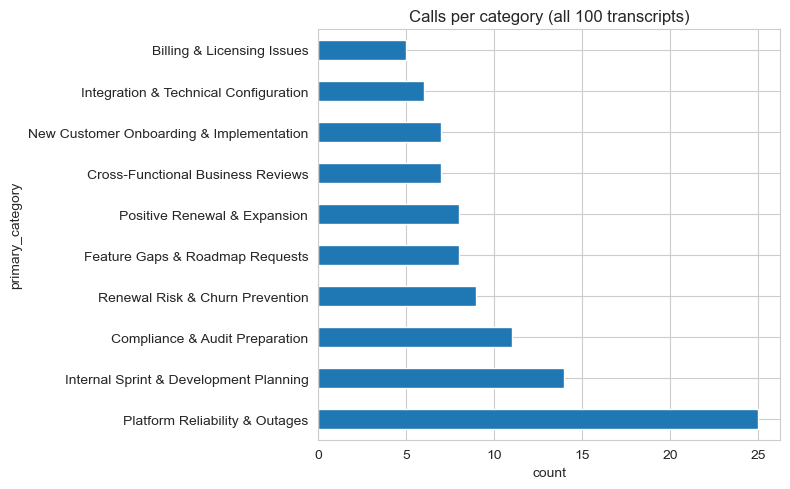

In [6]:
merged = df.merge(results, on="call_id")

fig, ax = plt.subplots(figsize=(8,5))
merged["primary_category"].value_counts().plot(kind="barh", ax=ax)
ax.set_title("Calls per category (all 100 transcripts)")
ax.set_xlabel("count")
plt.tight_layout()
plt.savefig("../outputs/figures/category_distribution.png", dpi=150)
plt.show()

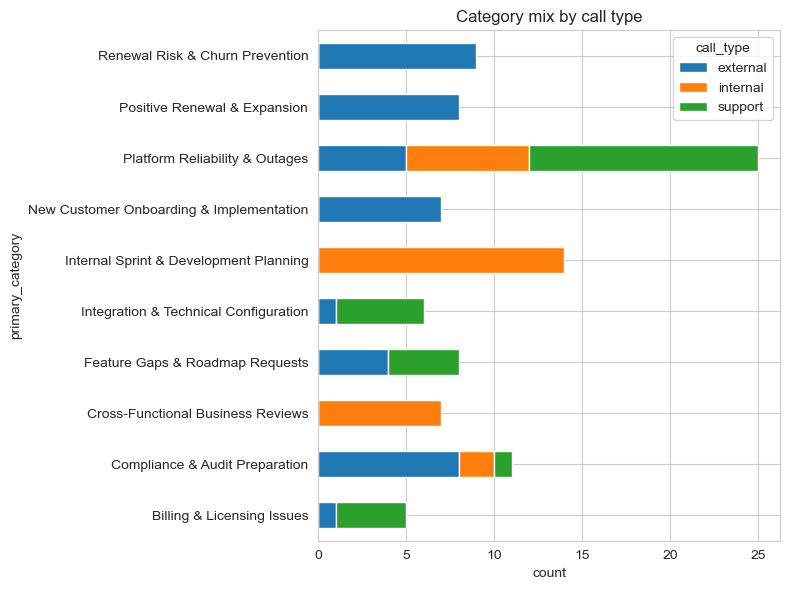

call_type,external,internal,support
primary_category,,,
Billing & Licensing Issues,1,0,4
Compliance & Audit Preparation,8,2,1
Cross-Functional Business Reviews,0,7,0
Feature Gaps & Roadmap Requests,4,0,4
Integration & Technical Configuration,1,0,5
Internal Sprint & Development Planning,0,14,0
New Customer Onboarding & Implementation,7,0,0
Platform Reliability & Outages,5,7,13
Positive Renewal & Expansion,8,0,0


In [7]:
# Category mix by call type -- which categories show up where?
ct = pd.crosstab(merged["primary_category"], merged["call_type"])
fig, ax = plt.subplots(figsize=(8,6))
ct.plot(kind="barh", stacked=True, ax=ax)
ax.set_title("Category mix by call type")
ax.set_xlabel("count")
plt.tight_layout()
plt.savefig("../outputs/figures/category_by_call_type.png", dpi=150)
plt.show()
ct

## Examples per category

Showing 2-3 representative transcripts per category, with the rationale the model gave, so we can sanity-check the classifications by reading actual examples rather than trusting the aggregate stats blindly.

In [8]:
for cat in merged["primary_category"].unique():
    print(f"\n{'='*80}\nCATEGORY: {cat}\n{'='*80}")
    examples = merged[merged["primary_category"] == cat].head(3)
    for r in examples.itertuples():
        print(f"\n[{r.call_id}] ({r.call_type}) {r.title}")
        print(f"  confidence: {r.confidence}")
        print(f"  rationale: {r.rationale}")


CATEGORY: Platform Reliability & Outages

[01KQ03B0303900521BB089CA] (internal) Detect Outage - Remediation Plan Review
  confidence: 0.98
  rationale: This is a day-three incident response call addressing a Detect product outage with cascading failure in the event processing pipeline, covering root cause analysis (single point of failure in event ingestion), remediation architecture (redundant active-active nodes, circuit breaker pattern), restoration timeline, and customer communication strategy.

[01KQ1A6B7E81B06F4A13B60D] (support) Support Case #6977 - Brightpath Commerce Slow Backup Performance
  confidence: 0.92
  rationale: This call addresses severe service degradation (backup jobs taking 4-6 hours vs. 90 minutes) caused by a known platform bug in version 3.4.1, with root cause analysis identifying the change block tracking issue and remediation planned through version upgrade to 3.6.0.

[01KQ2217B066855A3B7814CB] (external) Aegis / Meridian Capital - Service Reliability Discu

## Validation: comparing against the dataset's pre-existing `topics` field

The raw dataset ships with a `topics` field per call (free-text, multiple tags per call, no fixed taxonomy — presumably generated by whatever system originally produced these transcripts/summaries). I'm treating this as a **baseline for sanity-checking**, not ground truth, since:
- It's not a fixed, mutually-exclusive taxonomy (can't directly compare category-for-category)
- We don't know what model/prompt produced it

What I *can* check: does our primary category for each call show up, semantically, somewhere in that call's baseline topics list? This is a soft validation — it catches gross misclassifications without requiring the two taxonomies to match exactly.

In [9]:
# Soft validation: print a sample of calls where our category seems to have
# NO overlap at all with the baseline topics, for manual review
def topics_overlap(row):
    cat_words = set(row["primary_category"].lower().split())
    topic_words = set(" ".join(row["baseline_topics"]).lower().split())
    return len(cat_words & topic_words) > 0

merged["soft_overlap_with_baseline"] = merged.apply(topics_overlap, axis=1)
print(f"Soft overlap rate: {merged['soft_overlap_with_baseline'].mean():.0%}")

print("\nSample of calls with NO word-level overlap (worth a manual look, not necessarily wrong):")
no_overlap = merged[~merged["soft_overlap_with_baseline"]][["call_id","title","primary_category","baseline_topics"]].head(8)
no_overlap

Soft overlap rate: 72%

Sample of calls with NO word-level overlap (worth a manual look, not necessarily wrong):


,call_id,title,primary_category,baseline_topics
6,01KQ1A6B7E81B06F4A13B60D,Support Case #6977 - Brightpath Commerce Slow ...,Platform Reliability & Outages,"[backup performance, agent version update, tec..."
9,01KQ1DE954A807A5D2653175,Comply v2 - Launch Readiness Review,Internal Sprint & Development Planning,"[launch readiness, compliance reporting, api r..."
11,01KQ2331EFD78BF3B1CAB747,Detect Outage - Customer Impact Assessment,Platform Reliability & Outages,"[product outage, churn risk, sla compliance, i..."
13,01KQ298F2846EFE59B0D70E2,Competitive Threat Assessment - Post Outage,Cross-Functional Business Reviews,"[platform outage, competitive displacement, cu..."
15,01KQ2D93184912F0147315E7,URGENT: Blackridge Investments - Complete Loss...,Platform Reliability & Outages,"[service outage, threat monitoring failure, sl..."
17,01KQ325BDEDEE927D2970775,Support Case #5889 - Ridgeline Logistics Detec...,Platform Reliability & Outages,"[product outage, alert latency, sla breach, in..."
19,01KQ38C4101D6774F2F02331,INCIDENT: Detect Pipeline Failure - War Room,Platform Reliability & Outages,"[outage, pipeline failure, customer escalation..."
20,01KQ38FE02AEE5AA5157F042,Support Case #3296 - Pinnacle Insurance Comply...,Feature Gaps & Roadmap Requests,"[product bug, compliance reporting, pdf render..."


## Takeaways for Task 1

- **"Platform Reliability & Outages" is the single largest category and the
  only one that shows up meaningfully across all three call types** (external,
  internal, and support) -- 25 calls total (5 external, 7 internal, 13
  support). No other category crosses call-type boundaries this cleanly: most
  topics live inside one team's world (renewals are external-only, sprint
  planning is internal-only), but reliability problems ripple through every
  function. This is the throughline explored fully in the bonus insights
  notebook.
- **Support call volume is dominated by two themes**: reliability/outage
  symptoms (13 calls) and integration/technical configuration issues (5 calls)
  -- together explaining two thirds of support tickets in this sample.
- **External calls split cleanly along the customer lifecycle**: onboarding
  (7), positive renewals (8), at-risk renewals (9), and compliance/audit prep
  (8) each form a distinct, sizeable cluster -- useful for a sales/CS leader
  wanting a quick read on where in the lifecycle their external call volume
  sits.
- **The soft validation against the dataset's pre-existing topic tags showed
  72% word-level overlap**, with the non-overlapping 28% being reasonable
  differences in framing rather than misclassifications (e.g. a call tagged
  "churn risk" in the baseline vs. "Platform Reliability & Outages" in our
  taxonomy -- both valid, just different lenses on the same call). One
  notable case: the previously-failing call ("PDF Formatting Issue") landed
  in "Feature Gaps & Roadmap Requests" at only 0.4 confidence, with the model
  explicitly noting it's really a product bug that doesn't cleanly fit any
  category in the taxonomy -- a fair signal that an 11th category like
  "Product Defects & Quality Issues" could be worth adding in a v2 pass.
- See the slide deck for the leadership-facing version of these findings.